# Airbnb de Nueva York

## - Carga de la base de datos

In [1]:
#IMPORTAMOS LIBRERIAS
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#CARGAMOS LOS DATOS
df = pd.read_csv('../data/raw/AB_NYC_2019.csv')
df

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,NaN,2,9
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,NaN,2,36
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,NaN,1,27
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,NaN,6,2


## - Análisis descriptivo

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

In [4]:
df['number_of_reviews'].value_counts()

number_of_reviews
0      10052
1       5244
2       3465
3       2520
4       1994
       ...  
417        1
368        1
436        1
310        1
341        1
Name: count, Length: 394, dtype: int64

El dataframe posee 16 columnas y 48895 filas. 6 columnas corresponden a texto.

La variable name solo falta en 16 filas y host_name falta en 21

Las variables last_review y reviews_per_month faltan en 10052, un 20.6%, lo cual coincide con las propiedades que tiene 0 reviews.

## - Eliminación de duplicados y de información no esencial

In [5]:
total_duplicados = df.duplicated().sum()
print(f"El número de duplicado según id es: {df['id'].duplicated().sum()}")

El número de duplicado según id es: 0


In [6]:
df['host_id'].value_counts()

host_id
219517861    327
107434423    232
30283594     121
137358866    103
16098958      96
            ... 
274307600      1
274311461      1
274321313      1
23492952       1
68119814       1
Name: count, Length: 37457, dtype: int64

In [7]:
df['name'].value_counts()

name
Hillside Hotel                                       18
Home away from home                                  17
New york Multi-unit building                         16
Brooklyn Apartment                                   12
Loft Suite @ The Box House Hotel                     11
                                                     ..
Charming one bedroom - newly renovated rowhouse       1
Affordable room in Bushwick/East Williamsburg         1
Sunny Studio at Historical Neighborhood               1
43rd St. Time Square-cozy single bed                  1
Trendy duplex in the very heart of Hell's Kitchen     1
Name: count, Length: 47905, dtype: int64

In [8]:
resultado = df[df['name'] == 'Home away from home']
print(resultado)

             id                 name    host_id host_name neighbourhood_group  \
16309  13125243  Home away from home   46087238   Michion              Queens   
16522  13238321  Home away from home   40976536      Jeff           Manhattan   
24723  19856899  Home away from home   67739226     Vipul           Manhattan   
25100  20111316  Home away from home   15758568      Mike            Brooklyn   
29362  22517063  Home away from home  122283834       Eve              Queens   
30933  23963981  Home away from home  180208872     Ketia            Brooklyn   
33618  26604019  Home away from home   40398107      Joey            Brooklyn   
35636  28291780  Home away from home  213660495     Jamie              Queens   
36126  28716187  Home away from home  216611306       Eme              Queens   
36883  29316421  Home away from home  216738370      Mary           Manhattan   
36909  29338253  Home away from home  221022609     Lexus            Brooklyn   
37535  29780690  Home away f

No hay registros duplicados por id.

Se verificó además que hay anfitriones (host_id) que tienen hasta 327 publicaciones, pero no se consideran duplicados.

Hay nombres de lugares que están publicados hasta 18 veces. Tampoco son duplicados como el caso de "Home away from home", elegido por 17 diferentes personas de diferentes lugares.

In [9]:
df = df.drop(["id", "name", "host_name", "last_review", "reviews_per_month"], axis = 1)
df.head()

,host_id,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365
0,2787,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,6,365
1,2845,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2,355
2,4632,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,1,365
3,4869,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,1,194
4,7192,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,1,0


Se eliminaron las columnas redundantes y las que carecían de mucha información.

## - Análisis de variables categóricas

<Axes: xlabel='neighbourhood_group', ylabel='count'>

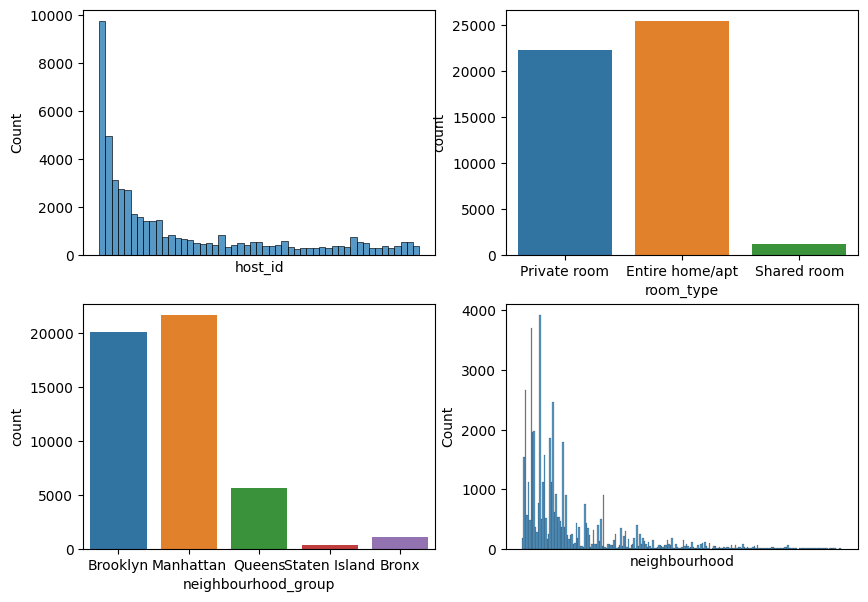

In [36]:
fig, axis = plt.subplots(2, 2, figsize=(10, 7))

sns.histplot(ax = axis[0,0], data = df, x = "host_id").set_xticks([])
#sns.countplot(ax = axis[0,0], data=df, x='host_id')
sns.countplot(ax = axis[0,1], data=df, x='room_type', hue ='room_type')
sns.histplot(ax = axis[1,1], data = df, x = "neighbourhood").set_xticks([])
sns.countplot(ax = axis[1,0], data=df, x='neighbourhood_group', hue ='neighbourhood_group')



In [38]:
df['neighbourhood'].value_counts()

neighbourhood
Williamsburg          3920
Bedford-Stuyvesant    3714
Harlem                2658
Bushwick              2465
Upper West Side       1971
                      ... 
Richmondtown             1
Fort Wadsworth           1
New Dorp                 1
Rossville                1
Willowbrook              1
Name: count, Length: 221, dtype: int64

In [41]:
manhattan_df = df[df['neighbourhood_group'] == 'Manhattan']
top_vecindario = manhattan_df['neighbourhood'].value_counts().idxmax()
total_ofertas = manhattan_df['neighbourhood'].value_counts().max()

print(f"El vecindario con más oferta en Manhattan es {top_vecindario} con {total_ofertas} alojamientos.")

El vecindario con más oferta en Manhattan es Harlem con 2658 alojamientos.


<Axes: xlabel='neighbourhood_group', ylabel='count'>

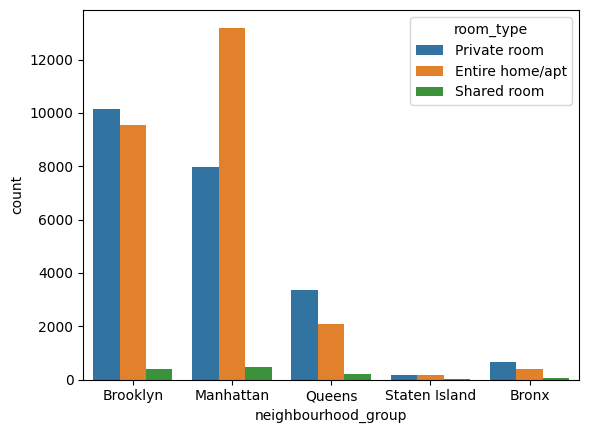

In [43]:
sns.countplot(data = df, x = "neighbourhood_group", hue = "room_type")

En la base de datos se ofrecen en su mayoría de casas enteras y habitaciones privadas; en menor proporción cuartos compartidos.

Los barrios que dominan la oferta son Manhattan y Brooklyn, Queens representa cerca de la cuarta parte de cada uno de ellos y en menor proporción se observan Staten Iland y el Bronx.

La cantidad de vecindarios es muy grande, estando los 2 con más ofertas en Brooklyn y el tercero en Manhattan.

El análisis entre las variables categóricas tipo de ambiente y barrio muestra que en 4 de los 5 barrios principales domina la oferta de habitaciones privadas, siendo Manhattan es el único lugar donde hay más oferta de apartamentos completos respecto a habitaciones privadas

## - Análisis de variables numéricas

In [ ]:
precios = df.groupby('neighbourhood_group').agg({'price':['count','sum','mean','std']})
precios

price                                 
                     count      sum        mean         std
neighbourhood_group                                        
Bronx                 1091    95459   87.496792  106.709349
Brooklyn             20104  2500600  124.383207  186.873538
Manhattan            21661  4264527  196.875814  291.383183
Queens                5666   563867   99.517649  167.102155
Staten Island          373    42825  114.812332  277.620403